## Graph features Enrichment

Based on the graph analysis, feature enrichment will include the following metrics. these features are not learned by the GNN.
The metrics are calculated and normalized per time-step, to avoid data-leak per time window, and account for the different graph sizes. 

1. Betweenness centrality 
2. closeness centrality
3. Eigenvector centrality
4. Pagerank
5. K-core [in/out]
6. HITS hub/authority

the features will be added to the entire ds, 
however the features normalizatoin scalar Z, be fitted to the training set
Train supervision: class 0/1 labels from t ≤ 35
  Val:  t = 36..40
  Test: t = 41..49  (predict class for all, evaluate on class 0/1 only)

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from networkx.algorithms import community

from sklearn.preprocessing import StandardScaler

%matplotlib inline


In [2]:
RANDOM_STATE=90
SAMPLE_TIME_STEP=35
TRAIN_TS = list(range(1,36))
np.random.seed(RANDOM_STATE)

## Load Data

In [3]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


In [4]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [5]:
feature_cols = local_cols + agg_cols

In [6]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [7]:
# map classes: licit - 0; illicit- 1;  unknown -2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True).astype(int)
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

In [8]:
df = pd.merge(features, classes, on='txId')

## Helper Functions

In [11]:
def create_timestep_subgraph(timestep, df=df):
    ts_nodes = df[df['time_step'] == timestep]['txId'].values                                                                  
    ts_edges = edges[edges['txId1'].isin(ts_nodes) & edges['txId2'].isin(ts_nodes)]        
    G_ts = nx.from_pandas_edgelist(                                                                                            
        ts_edges, source='txId1', target='txId2', create_using=nx.DiGraph()
    )
    return G_ts


                                                                                   

In [12]:
def plot_metric_per_class(centrality_scores, metric_name, df, timestep=None):                                              
    """                                                                                                                    
    Distribution of a graph metric split by class (licit=0, illicit=1).                                                    
    centrality_scores: dict {txId: score}                                                                                  
    """                                                                                                                    
    label_map = dict(zip(classes['txId'], classes['class']))                                                               
                                                                                                                            
    # build dataframe: only labeled nodes (class 0/1)                                                                      
    records = [                                                                                                            
        {'txId': node, 'score': score, 'class': label_map.get(node, 2)}                                                    
        for node, score in centrality_scores.items()                                                                       
    ]                                                                                                                      
    metric_df = pd.DataFrame(records)                                                                                      
    metric_df = metric_df[metric_df['class'] < 2]   # drop unknown                                                         
                                                                                                                            
    licit   = metric_df[metric_df['class'] == 0]['score']                                                                  
    illicit = metric_df[metric_df['class'] == 1]['score']                                                                  
                                                                                                                            
    title_suffix = f' — Timestep {timestep}' if timestep else ''                                                           
    colors = {0: 'steelblue', 1: 'crimson'}
    labels = {0: f'Licit (n={len(licit)})', 1: f'Illicit (n={len(illicit)})'}                                              
                                                                                                                            
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                        
    fig.suptitle(f'{metric_name} per Class{title_suffix}', fontsize=12)                                                    
                                                                                                                            
    # Panel 1: histogram (log1p scale for skewed distributions)                                                            
    ax = axes[0]                                                                                                           
    for cls, data in [(0, licit), (1, illicit)]:                                                                           
        ax.hist(np.log1p(data), bins=40, alpha=0.5,                                                                        
                color=colors[cls], label=labels[cls], density=True)                                                        
    ax.set_xlabel(f'log(1 + {metric_name})')                                                                               
    ax.set_ylabel('Density')                                                                                               
    ax.set_title('Distribution (log1p scale)')
    ax.legend()                                                                                                            
                                                                                                                            
    # Panel 2: box plot per class
    ax = axes[1]                                                                                                           
    ax.boxplot([licit, illicit], tick_labels=['Licit', 'Illicit'],
                patch_artist=True,                                                                                          
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='black', linewidth=2))                                                               
    boxes = ax.patches                                                                                                     
    if len(boxes) >= 2:
        boxes[1].set_facecolor('crimson')                                                                                  
    ax.set_ylabel(metric_name)                                                                                             
    ax.set_title('Box Plot')
    ax.set_yscale('log' if metric_df['score'].max() > 0 else 'linear')                                                     
                                                                                                                            
    # Panel 3: fraction of zeros per class                                                                                 
    ax = axes[2]                                                                                                           
    zero_frac = {
        'Licit':   (licit == 0).mean(),
        'Illicit': (illicit == 0).mean()                                                                                   
    }
    ax.bar(zero_frac.keys(), zero_frac.values(),                                                                           
            color=['steelblue', 'crimson'], alpha=0.7)                                                                      
    ax.set_ylabel('Fraction with score = 0')
    ax.set_title('Zero-score Nodes')                                                                                       
    ax.set_ylim(0, 1)
    for i, (k, v) in enumerate(zero_frac.items()):                                                                         
        ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)
                                                                                                                            
    plt.tight_layout()
    plt.show()   
    # summary stats
    print(f"\n{metric_name} summary (timestep {timestep}):")
    print(metric_df.groupby('class')['score'].describe().round(6))        

##  Class distribution Analysis

### Betweenness Centrality

In [17]:
G_sts = create_timestep_subgraph(1)      

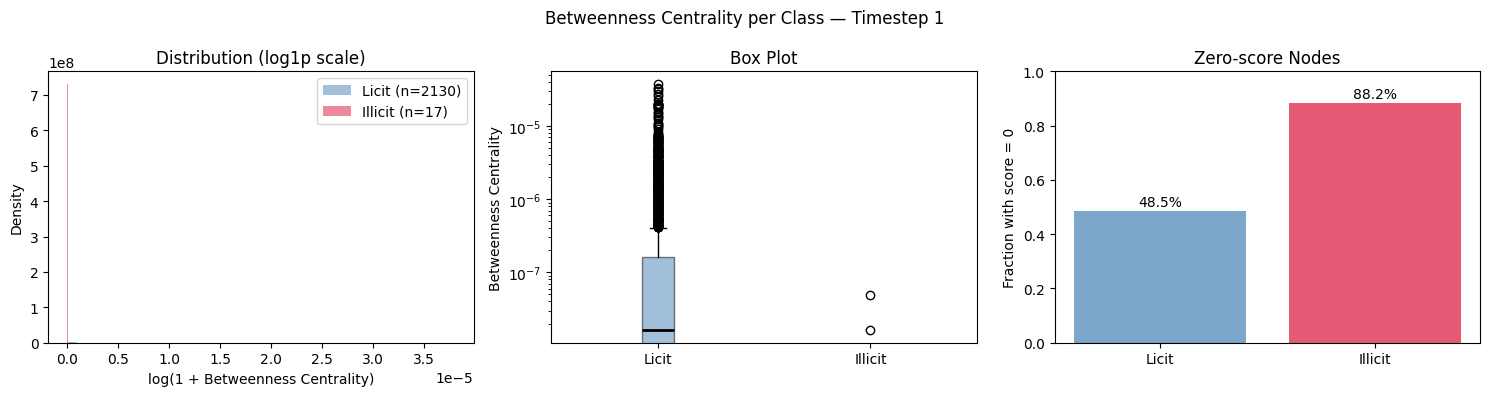


Betweenness Centrality summary (timestep 1):
        count      mean       std  min  25%  50%  75%       max
class                                                          
0      2130.0  0.000001  0.000003  0.0  0.0  0.0  0.0  0.000038
1        17.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000


In [18]:
betweenness = nx.betweenness_centrality(G_sts)
plot_metric_per_class(betweenness, 'Betweenness Centrality', df, timestep=1)

- Panel 3 (right): 88.2% of illicit nodes have zero betweenness vs 48.5% of licit. This is the key finding — illicit nodes 
  are overwhelmingly leaf nodes in the transaction flow. They don't sit on any shortest path between other nodes. They're    
  endpoints, not relays.                                                                                                     
  - Panel 1 (left): The tall vertical line at x=0 for illicit confirms the same thing — almost all illicit scores are exactly
   zero, so log1p(0)=0, all mass is at one point. The licit distribution is wider because ~51.5% of licit nodes do have      
  non-zero betweenness. 
  - Panel 2 (middle): Licit nodes have a much wider spread with many outliers at the top — some licit nodes are genuine      
  hubs/relays with high betweenness. The illicit box is compressed near zero with just 2-3 outliers.                         
                        
  The interpretation for fraud detection:                                                                                    
                        
  Illicit transactions tend to be terminal cash-out points — they receive funds and stop. They don't forward to multiple     
  destinations, so they never appear on shortest paths between other transactions. Licit nodes are more likely to be
  intermediate relay nodes in the flow network.

### Closeness Centrality

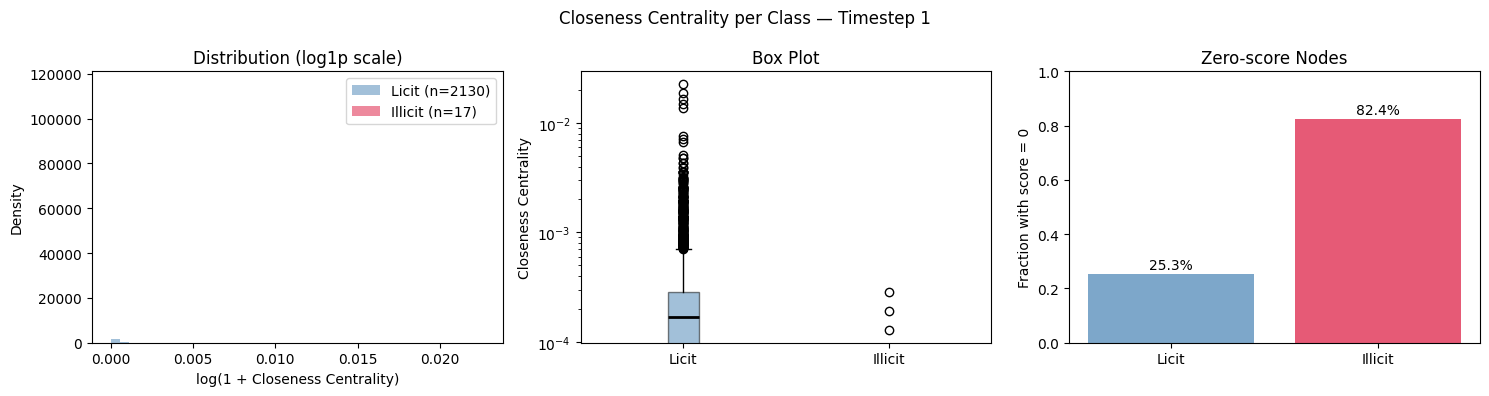


Closeness Centrality summary (timestep 1):
        count      mean       std  min  25%       50%       75%       max
class                                                                    
0      2130.0  0.000369  0.001034  0.0  0.0  0.000169  0.000282  0.022928
1        17.0  0.000035  0.000084  0.0  0.0  0.000000  0.000000  0.000286


In [19]:
                                          
closeness = nx.closeness_centrality(G_sts)
plot_metric_per_class(closeness, 'Closeness Centrality', df, timestep=1)

### Eigenvector Centrality

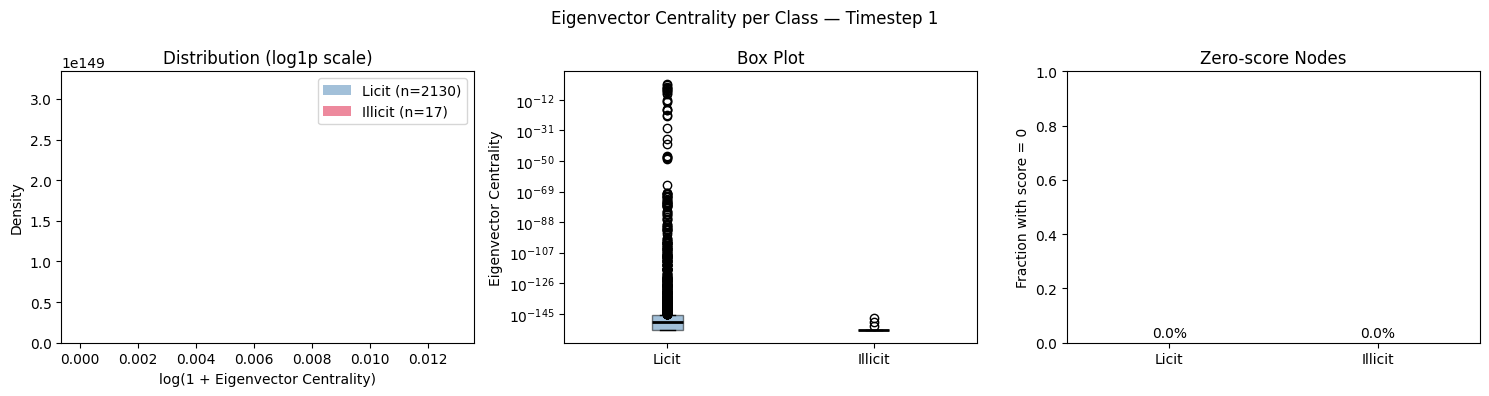


Eigenvector Centrality summary (timestep 1):
        count      mean       std  min  25%  50%  75%       max
class                                                          
0      2130.0  0.000008  0.000293  0.0  0.0  0.0  0.0  0.013015
1        17.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000


In [20]:
eigen_centrality = nx.eigenvector_centrality(G_sts, max_iter=1000)
plot_metric_per_class(eigen_centrality, 'Eigenvector Centrality', df, timestep=1)

Eigen-value centrality is very small, does not add any information therefore will not be included. 

### Page Rank

/tmp/ipykernel_11970/401441885.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([licit, illicit], labels=['Licit', 'Illicit'],


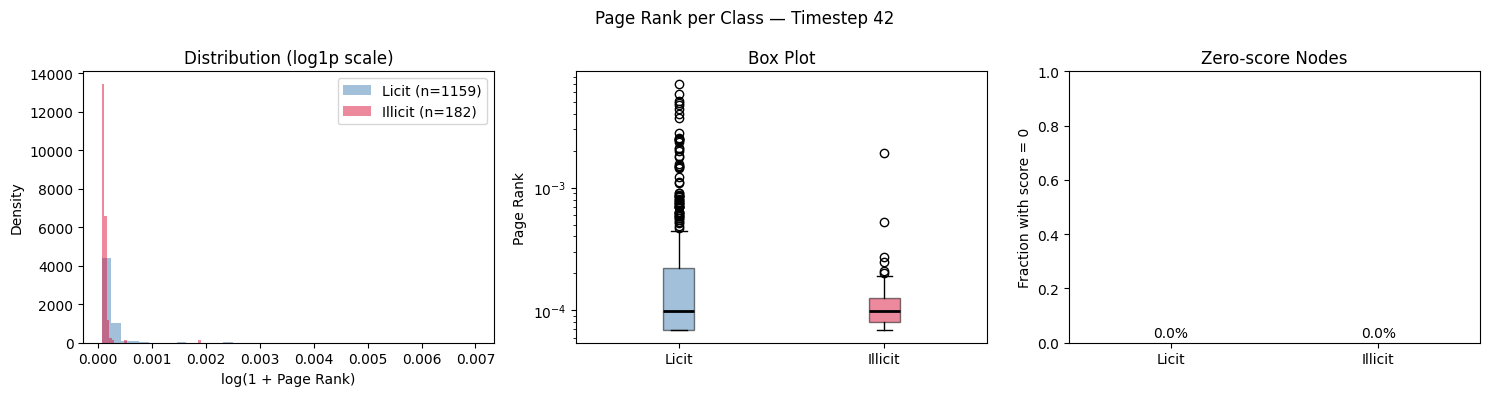


Page Rank summary (timestep 42):
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      1159.0  0.000225  0.000486  0.000069  0.000069  0.000098  0.000222   
1       182.0  0.000121  0.000141  0.000069  0.000081  0.000098  0.000127   

            max  
class            
0      0.007025  
1      0.001904  


In [52]:
page_rank = nx.pagerank(G_sts, alpha=0.85)     
plot_metric_per_class(page_rank, 'Page Rank', df, timestep=42)                                                                       


### HITS

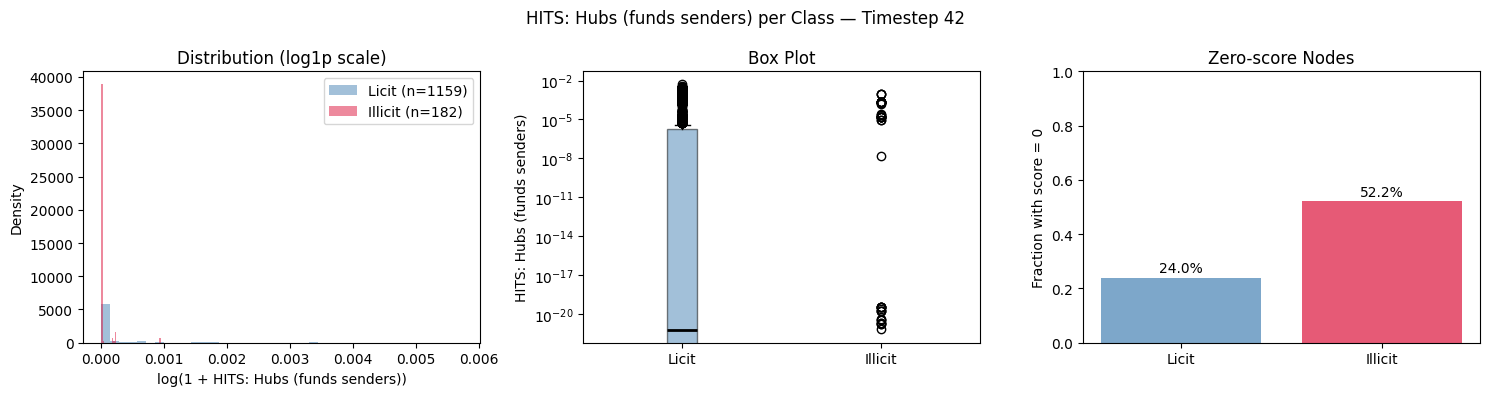


HITS: Hubs (funds senders) summary (timestep 42):
        count      mean       std  min  25%  50%       75%       max
class                                                               
0      1159.0  0.000187  0.000592 -0.0 -0.0  0.0  0.000002  0.005747
1       182.0  0.000029  0.000128 -0.0  0.0 -0.0 -0.000000  0.000944


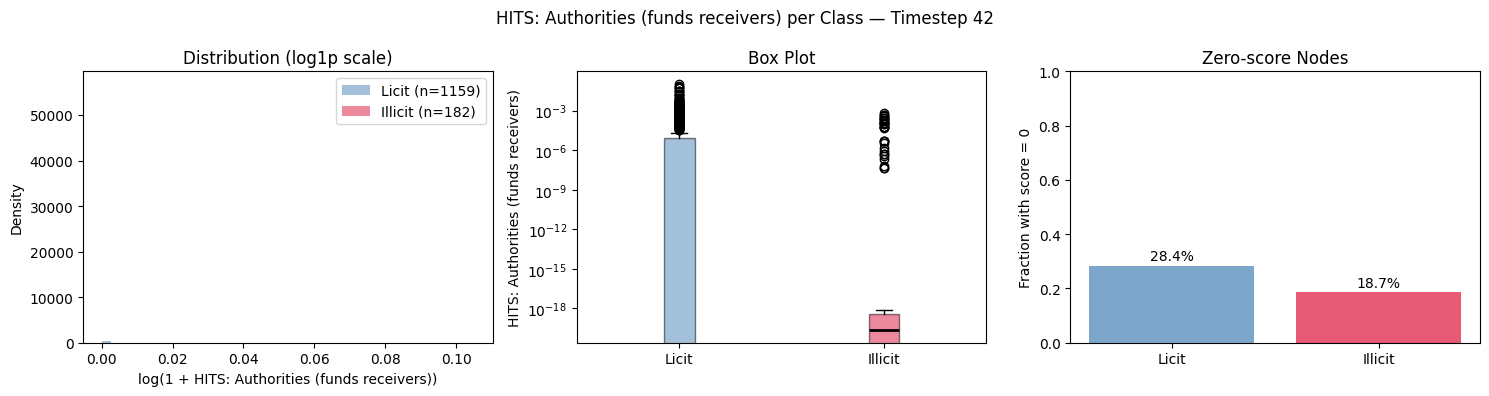


HITS: Authorities (funds receivers) summary (timestep 42):
        count      mean       std  min  25%  50%       75%       max
class                                                               
0      1159.0  0.000699  0.005183 -0.0 -0.0  0.0  0.000009  0.110852
1       182.0  0.000023  0.000084 -0.0 -0.0  0.0  0.000000  0.000624


In [55]:
hubs, auths = nx.hits(G_sts, max_iter=1000)       
plot_metric_per_class(hubs, 'HITS: Hubs (funds senders)', df, timestep=42)                                                                       
plot_metric_per_class(auths, 'HITS: Authorities (funds receivers)', df, timestep=42)                                                                       


### In and Out Core

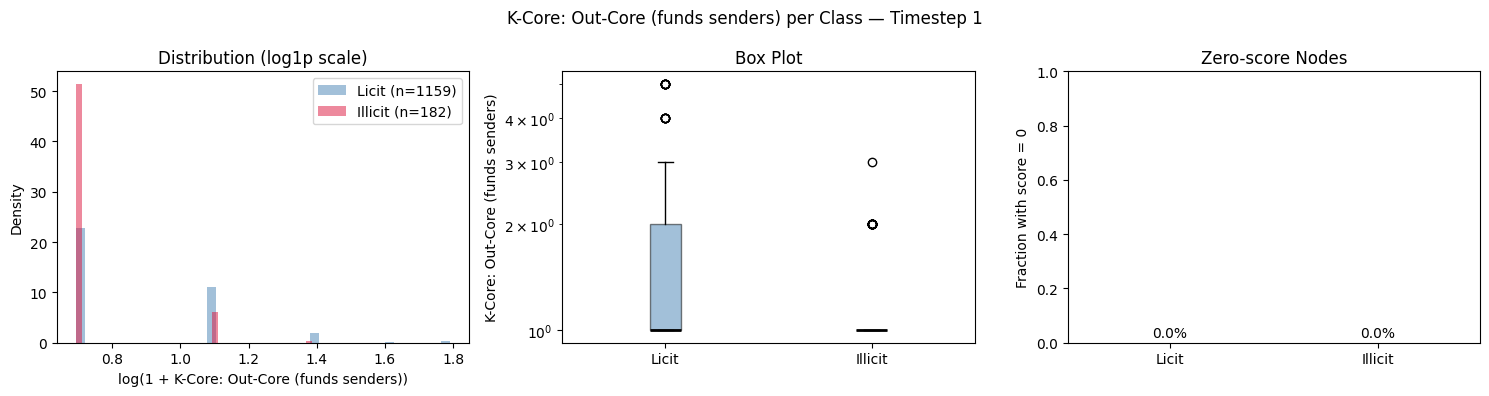


K-Core: Out-Core (funds senders) summary (timestep 1):
        count      mean       std  min  25%  50%  75%  max
class                                                     
0      1159.0  1.458154  0.687741  1.0  1.0  1.0  2.0  5.0
1       182.0  1.115385  0.337172  1.0  1.0  1.0  1.0  3.0


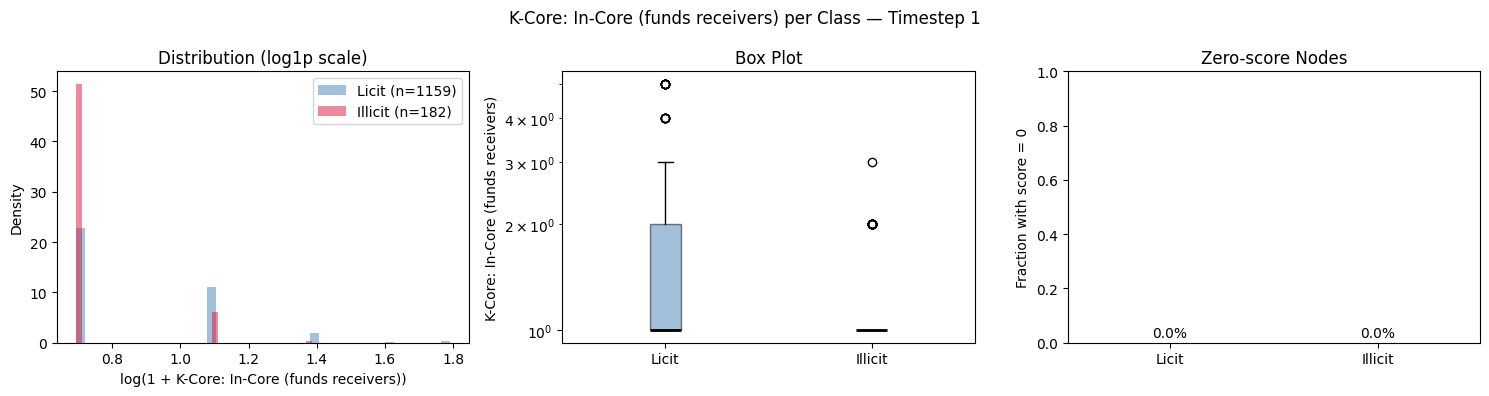


K-Core: In-Core (funds receivers) summary (timestep 1):
        count      mean       std  min  25%  50%  75%  max
class                                                     
0      1159.0  1.458154  0.687741  1.0  1.0  1.0  2.0  5.0
1       182.0  1.115385  0.337172  1.0  1.0  1.0  1.0  3.0


In [57]:
out_core = nx.core_number(G_sts)            # out-degree perspective                                                    
in_core  = nx.core_number(G_sts.reverse())  

plot_metric_per_class(out_core, 'K-Core: Out-Core (funds senders)', df, timestep=1)                                                                       
plot_metric_per_class(in_core, 'K-Core: In-Core (funds receivers)', df, timestep=1)                                                                       



## Feature enrichment

### Preparation

In [13]:
# create graph
graph = nx.Graph()

graph = nx.from_pandas_edgelist(edges, 'txId1', 'txId2')

In [14]:
tss = df['time_step'].unique()


In [15]:
betweenness_records = []                                                                                                   
closeness_records   = []                                                                                                 
pagerank_records    = []
hub_records         = []
authority_records   = [] 
in_core_records     = []
out_core_records    = [] 


In [29]:
df_enriched = df.copy()
for ts in tss:                
    print(f'time step {ts}')                                                                
    G_ts = create_timestep_subgraph(ts)                                                                                  

    bc = nx.betweenness_centrality(G_ts)                                                                          
    cc = nx.closeness_centrality(G_ts)
    pr = nx.pagerank(G_ts, alpha=0.85)                                                                            
    hubs, auths = nx.hits(G_ts, max_iter=1000)       
    out_core = nx.core_number(G_ts)            # out-degree perspective                                                    
    in_core  = nx.core_number(G_ts.reverse())  # in-degree perspective 

    try:                                                                                                                   
        ec = nx.eigenvector_centrality(G_ts, max_iter=1000)
    except nx.PowerIterationFailedConvergence:                                                                             
        ec = {n: 0.0 for n in G_ts.nodes()}    

    ts_mask = df_enriched['time_step'] == ts                                                                                                                                                                                                                                                                                
    for col, scores in [('betweenness', bc), ('closeness', cc),                                                                                                                                                                                                                                                    
                        ('pagerank', pr), ('hits_hub', hubs),                                                                                                                                                                                                                                                      
                        ('hits_auth', auths), ('out_core', out_core),                                                                                                                                                                                                                                              
                        ('in_core', in_core), ('eigenvector', ec)]:                                                                                                                                                                                                                                                
        df_enriched.loc[ts_mask, col] = df_enriched.loc[ts_mask, 'txId'].map(scores)                                                                         
                                                                                                                            
    # for node in G_ts.nodes():                                                                                            
    #     betweenness_records.append({'txId': node, 'time_step': ts, 'betweenness': bc.get(node, 0.0)})
    #     closeness_records.append(  {'txId': node, 'time_step': ts, 'closeness':   cc.get(node, 0.0)})                      
    #     pagerank_records.append(   {'txId': node, 'time_step': ts, 'pagerank':    pr.get(node, 0.0)})                      
    #     hub_records.append(        {'txId': node, 'time_step': ts, 'hits_hub':    hubs.get(node, 0.0)})                    
    #     authority_records.append(  {'txId': node, 'time_step': ts, 'hits_auth':   auths.get(node, 0.0)})  
    #     out_core_records.append({'txId': node, 'time_step': ts, 'out_core': out_core.get(node, 0)})
    #     in_core_records.append( {'txId': node, 'time_step': ts, 'in_core':  in_core.get(node,  0)})                 
 

time step 1
time step 2
time step 3
time step 4
time step 5
time step 6
time step 7
time step 8
time step 9
time step 10
time step 11
time step 12
time step 13
time step 14
time step 15
time step 16
time step 17
time step 18
time step 19
time step 20
time step 21
time step 22
time step 23
time step 24
time step 25
time step 26
time step 27
time step 28
time step 29
time step 30
time step 31
time step 32
time step 33
time step 34
time step 35
time step 36
time step 37
time step 38
time step 39
time step 40
time step 41
time step 42
time step 43
time step 44
time step 45
time step 46
time step 47
time step 48
time step 49


In [30]:
# after the loop on tss[:2], check:                                                                                                                                                                                                                                                                                
df_enriched[['txId', 'time_step', 'betweenness', 'pagerank']].head(10)     

,txId,time_step,betweenness,pagerank
0,230425980,1,2.255490e-07,0.000105
1,5530458,1,1.288852e-07,0.000130
2,232022460,1,4.833193e-07,0.000130
3,232438397,1,3.794057e-05,0.007200
4,230460314,1,2.698917e-07,0.000055
5,230459870,1,3.963484e-06,0.000070
6,230333930,1,0.000000e+00,0.000041
7,230595899,1,6.170377e-06,0.000187
8,232013274,1,0.000000e+00,0.000041
9,232029206,1,1.970332e-05,0.001842


In [31]:
                                                                                                                                                                                                                                 
df_enriched[df_enriched['time_step'].isin([1])]

,txId,time_step,lf_1,lf_2,lf_3,lf_4,lf_5,lf_6,lf_7,lf_8,...,af_72,class,betweenness,closeness,pagerank,hits_hub,hits_auth,out_core,in_core,eigenvector
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.119792,2,2.255490e-07,0.000222,0.000105,-8.967309e-21,-0.000000e+00,1.0,1.0,1.248155e-140
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.119792,2,1.288852e-07,0.000226,0.000130,-3.752252e-20,-2.122902e-20,1.0,1.0,8.472258e-139
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.119792,2,4.833193e-07,0.000190,0.000130,8.715013e-05,2.577186e-19,1.0,1.0,1.183912e-148
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.119792,0,3.794057e-05,0.022928,0.007200,-6.668398e-20,2.056046e-04,2.0,2.0,5.101674e-130
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.179117,2,2.698917e-07,0.000286,0.000055,2.390113e-10,1.339972e-12,5.0,5.0,1.196851e-148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7875,230658152,1,-0.172879,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163539,...,-1.760984,2,0.000000e+00,0.000000,0.000041,-1.277603e-18,-0.000000e+00,1.0,1.0,4.292858e-156
7876,54735200,1,-0.172980,-0.184668,-1.201369,-0.046932,-0.043875,-0.029140,-0.061584,-0.163645,...,1.521399,0,0.000000e+00,0.000169,0.000090,-0.000000e+00,4.593004e-19,1.0,1.0,6.481186e-151
7877,230551382,1,-0.167408,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.157941,...,-1.760984,2,0.000000e+00,0.000000,0.000041,1.548580e-03,-0.000000e+00,1.0,1.0,4.292858e-156
7878,33654709,1,-0.169357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.159935,...,-0.119792,2,0.000000e+00,0.000127,0.000058,-0.000000e+00,-1.606077e-19,1.0,1.0,2.361072e-153


In [ ]:
                                                                                                                            
  #Normalization — per timestep, scaler fit on train only:                                                                    
def normalize_per_timestep(records, metric_col, train_ts=TRAIN_TS):                                                        
    metric_df = pd.DataFrame(records)                                                                                      
    normalized = []                                                                                                        
                    
    scalers = {}                                                                                                           
    # fit on each training timestep                                                                                      
    for ts in sorted(train_ts):    
        ts_data = metric_df[metric_df['time_step'] == ts][[metric_col]]                                                    
        scaler = StandardScaler()                                      
        scaler.fit(ts_data)                                                                                                
        scalers[ts] = scaler                                                                                             
                                                                                                                            
    last_train_scaler = scalers[max(train_ts)]                                                                             
                                            
    for ts, group in metric_df.groupby('time_step'):                                                                       
        scaler = scalers.get(ts, last_train_scaler)                                                                        
        group = group.copy()                       
        group[f'{metric_col}_norm'] = scaler.transform(group[[metric_col]])                                                
        normalized.append(group[['txId', f'{metric_col}_norm']])                                                           
                                                                
    return pd.concat(normalized, ignore_index=True) 

In [34]:
df.shape

(203769, 168)

In [33]:
df_enriched.head( )

,txId,time_step,lf_1,lf_2,lf_3,lf_4,lf_5,lf_6,lf_7,lf_8,...,af_72,class,betweenness,closeness,pagerank,hits_hub,hits_auth,out_core,in_core,eigenvector
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.119792,2,2.255490e-07,0.000222,0.000105,-8.967309e-21,-0.000000e+00,1.0,1.0,1.248155e-140
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.119792,2,1.288852e-07,0.000226,0.000130,-3.752252e-20,-2.122902e-20,1.0,1.0,8.472258e-139
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.119792,2,4.833193e-07,0.000190,0.000130,8.715013e-05,2.577186e-19,1.0,1.0,1.183912e-148
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.119792,0,3.794057e-05,0.022928,0.007200,-6.668398e-20,2.056046e-04,2.0,2.0,5.101674e-130
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.179117,2,2.698917e-07,0.000286,0.000055,2.390113e-10,1.339972e-12,5.0,5.0,1.196851e-148


In [35]:
df_enriched.to_csv('./data/elliptic_enriched.csv', index=False)
